# Experiment No. 08 — Simulated Annealing for Function Optimization


---

## 1. Problem + Algorithm

### Title
Simulated Annealing for Function Optimization.

### Aim
Implement Simulated Annealing to minimize a given objective function.

### Problem Statement
Minimize

$$f(x) = x^{2} - 6x + 13$$

using the Simulated Annealing (SA) algorithm with the settings below. The
acceptance of worsening moves is decided using the supplied random numbers.

### Given Parameter Settings

| Parameter | Symbol | Value |
|---|---|---|
| Objective function | $f(x)$ | $x^2 - 6x + 13$ |
| Initial solution | $x_0$ | $1$ |
| Initial temperature | $T_0$ | $10$ |
| Cooling factor | $\alpha$ | $0.5$ |
| Minimum temperature (stopping criterion) | $T_{min}$ | $1$ |
| Neighbour rule | $x'$ | $x \pm 1$ |
| Random numbers | $r_1, r_2, r_3, r_4$ | $0.30,\; 0.80,\; 0.20,\; 0.90$ |

### Algorithm
1. **Initialize solution** $x \leftarrow x_0$ and evaluate $f(x)$.
2. **Set initial temperature** $T \leftarrow T_0$.
3. **Generate neighbouring solution** $x' = x \pm 1$.
4. **Calculate change in objective function** $\Delta f = f(x') - f(x)$.
5. **Accept / reject according to probability:**
   - $\Delta f < 0$ (improvement) → accept unconditionally, no random number used;
   - $\Delta f \ge 0$ (worse) → compute $P = e^{-\Delta f / T}$ and accept only
     if the next random number $r < P$, otherwise reject and stay at $x$.
6. **Reduce temperature** geometrically: $T \leftarrow \alpha T$.
7. **Repeat** steps 3–6 until the stopping criterion $T < T_{min}$ is met.
8. **Return best solution** — the lowest-cost point seen at any time, tracked
   separately from the current solution.

### Note on the cooling schedule
With $T_0 = 10$, $\alpha = 0.5$ and $T_{min} = 1$:

$$10 \rightarrow 5 \rightarrow 2.5 \rightarrow 1.25 \rightarrow 0.625 \;(< T_{min},\ \text{stop})$$

so the run lasts **exactly four iterations**, and the four supplied random
numbers are more than enough to cover every worsening move that arises.

---

## 2. Program

### Function definition

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)


def f(x):
    # Objective function to be minimized: f(x) = x^2 - 6x + 13
    return x**2 - 6*x + 13


# quick inspection of the function near the expected optimum
table = pd.DataFrame({'x': range(0, 7), 'f(x)': [f(x) for x in range(0, 7)]})
print(table.to_string(index=False))

 x  f(x)
 0    13
 1     8
 2     5
 3     4
 4     5
 5     8
 6    13


### Core algorithm

The neighbour rule is $x' = x \pm 1$. The worked run steps **upward**
($x' = x + 1$), which is what `direction='up'` reproduces. `direction='random'`
chooses $+1$ or $-1$ with equal probability and is used for the longer runs in
the parameter study.

In [2]:
def simulated_annealing(x0=1, T0=10.0, alpha=0.5, T_min=1.0,
                        random_numbers=(0.30, 0.80, 0.20, 0.90),
                        direction='up', seed=0, max_iter=500):
    # Minimize f(x) = x^2 - 6x + 13 by Simulated Annealing.
    # Returns best_x, best_f and a DataFrame logging every iteration.
    rng = np.random.default_rng(seed)
    supplied = list(random_numbers)
    r_index = 0

    x = x0
    best_x, best_f = x, f(x)
    T = float(T0)
    records = []
    iteration = 0

    while T >= T_min and iteration < max_iter:
        iteration += 1

        # Step 3 - generate neighbouring solution x' = x +/- 1
        x_current = x
        step = +1 if direction == 'up' else int(rng.choice([-1, +1]))
        x_neighbor = x_current + step

        fx, fx_new = f(x_current), f(x_neighbor)

        # Step 4 - calculate change in objective function
        delta_f = fx_new - fx

        # Step 5 - accept / reject according to probability
        if delta_f < 0:
            P, r_used, decision = 1.0, None, 'Accept'
            x = x_neighbor
        else:
            P = math.exp(-delta_f / T)
            if r_index < len(supplied):        # supplied random numbers first
                r_used = supplied[r_index]
                r_index += 1
            else:                              # then continue with the RNG
                r_used = round(float(rng.random()), 4)
            if r_used < P:
                decision, x = 'Accept', x_neighbor
            else:
                decision = 'Reject'            # x stays at x_current

        # track the best solution seen so far
        if f(x) < best_f:
            best_x, best_f = x, f(x)

        records.append({'Iteration': iteration, 'T': T,
                        'Current x': x_current, 'Neighbour': x_neighbor,
                        'f(x)': fx, 'f(neighbour)': fx_new,
                        'Delta f': delta_f, 'P': round(P, 4),
                        'Random r': r_used, 'Decision': decision,
                        'Best x': best_x, 'Best f(x)': best_f})

        # Step 6 - reduce temperature
        T *= alpha

    return best_x, best_f, pd.DataFrame(records)

### Key parameter settings (original configuration)

In [3]:
PARAMS = dict(x0=1, T0=10.0, alpha=0.5, T_min=1.0,
              random_numbers=(0.30, 0.80, 0.20, 0.90), direction='up')

for k, v in PARAMS.items():
    print(f"{k:16s} = {v}")

x0               = 1
T0               = 10.0
alpha            = 0.5
T_min            = 1.0
random_numbers   = (0.3, 0.8, 0.2, 0.9)
direction        = up


---

## 3. Output + Analysis

### 3.1 Program Execution (original parameters)

In [4]:
best_x, best_f, hist = simulated_annealing(**PARAMS)

print(f"Initial Solution : {PARAMS['x0']}")
print(f"Initial Fitness  : {f(PARAMS['x0'])}")
print()

for _, row in hist.iterrows():
    print(f"Iteration {int(row['Iteration'])}")
    print(f"  Temperature T    : {row['T']}")
    print(f"  Current Solution : {row['Current x']}    f(x)         = {row['f(x)']}")
    print(f"  Neighbour x'     : {row['Neighbour']}    f(neighbour) = {row['f(neighbour)']}")
    print(f"  Delta f          : {row['Delta f']}")
    print(f"  P = exp(-df/T)   : {row['P']}      Random r = {row['Random r']}")
    print(f"  Decision         : {row['Decision']}")
    print(f"  Best so far      : x = {row['Best x']}, f(x) = {row['Best f(x)']}")
    print()

print(f"Final Solution   : {best_x}")
print(f"Minimum Value    : {best_f}")

Initial Solution : 1
Initial Fitness  : 8

Iteration 1
  Temperature T    : 10.0
  Current Solution : 1    f(x)         = 8
  Neighbour x'     : 2    f(neighbour) = 5
  Delta f          : -3
  P = exp(-df/T)   : 1.0      Random r = nan
  Decision         : Accept
  Best so far      : x = 2, f(x) = 5

Iteration 2
  Temperature T    : 5.0
  Current Solution : 2    f(x)         = 5
  Neighbour x'     : 3    f(neighbour) = 4
  Delta f          : -1
  P = exp(-df/T)   : 1.0      Random r = nan
  Decision         : Accept
  Best so far      : x = 3, f(x) = 4

Iteration 3
  Temperature T    : 2.5
  Current Solution : 3    f(x)         = 4
  Neighbour x'     : 4    f(neighbour) = 5
  Delta f          : 1
  P = exp(-df/T)   : 0.6703      Random r = 0.3
  Decision         : Accept
  Best so far      : x = 3, f(x) = 4

Iteration 4
  Temperature T    : 1.25
  Current Solution : 4    f(x)         = 5
  Neighbour x'     : 5    f(neighbour) = 8
  Delta f          : 3
  P = exp(-df/T)   : 0.0907      

### 3.2 Iteration Table

In [5]:
hist

,Iteration,T,Current x,Neighbour,f(x),f(neighbour),Delta f,P,Random r,Decision,Best x,Best f(x)
0,1,10.00,1,2,8,5,-3,1.0000,NaN,Accept,2,5
1,2,5.00,2,3,5,4,-1,1.0000,NaN,Accept,3,4
2,3,2.50,3,4,4,5,1,0.6703,0.3,Accept,3,4
3,4,1.25,4,5,5,8,3,0.0907,0.8,Reject,3,4


### 3.3 Final Result

In [6]:
result = pd.DataFrame({
    'Quantity': ['Objective function', 'Initial solution x0',
                 'Initial fitness f(x0)', 'Iterations performed',
                 'Final optimal solution x*', 'Minimum function value f(x*)',
                 'Execution status'],
    'Value': ['f(x) = x^2 - 6x + 13', PARAMS['x0'], f(PARAMS['x0']),
              len(hist), best_x, best_f, 'Successfully Executed']
})
result

,Quantity,Value
0,Objective function,f(x) = x^2 - 6x + 13
1,Initial solution x0,1
2,Initial fitness f(x0),8
3,Iterations performed,4
4,Final optimal solution x*,3
5,Minimum function value f(x*),4
6,Execution status,Successfully Executed


### 3.4 Analytical Verification

$$f'(x) = 2x - 6 = 0 \;\Rightarrow\; x = 3, \qquad f''(x) = 2 > 0$$

so $x = 3$ is the unique global minimum of this convex function, with
$f(3) = 9 - 18 + 13 = 4$.

In [7]:
import sympy as sp

xs = sp.symbols('x')
f_sym = xs**2 - 6*xs + 13
f1, f2 = sp.diff(f_sym, xs), sp.diff(f_sym, xs, 2)
crit = sp.solve(sp.Eq(f1, 0), xs)[0]

print(f"f(x)   = {f_sym}")
print(f"f'(x)  = {f1}  = 0   ->   x = {crit}")
print(f"f''(x) = {f2} > 0    ->   minimum")
print(f"f({crit})   = {f_sym.subs(xs, crit)}")
print()
print(f"SA result : x* = {best_x}, f(x*) = {best_f}")
print("Match with analytical optimum :",
      "YES" if (best_x == crit and best_f == f_sym.subs(xs, crit)) else "NO")

f(x)   = x**2 - 6*x + 13
f'(x)  = 2*x - 6  = 0   ->   x = 3
f''(x) = 2 > 0    ->   minimum
f(3)   = 4

SA result : x* = 3, f(x*) = 4
Match with analytical optimum : YES


### 3.5 Convergence Graph

- **X-axis** → Iteration
- **Y-axis** → Best objective-function value

The graph demonstrates how the solution approaches the minimum.

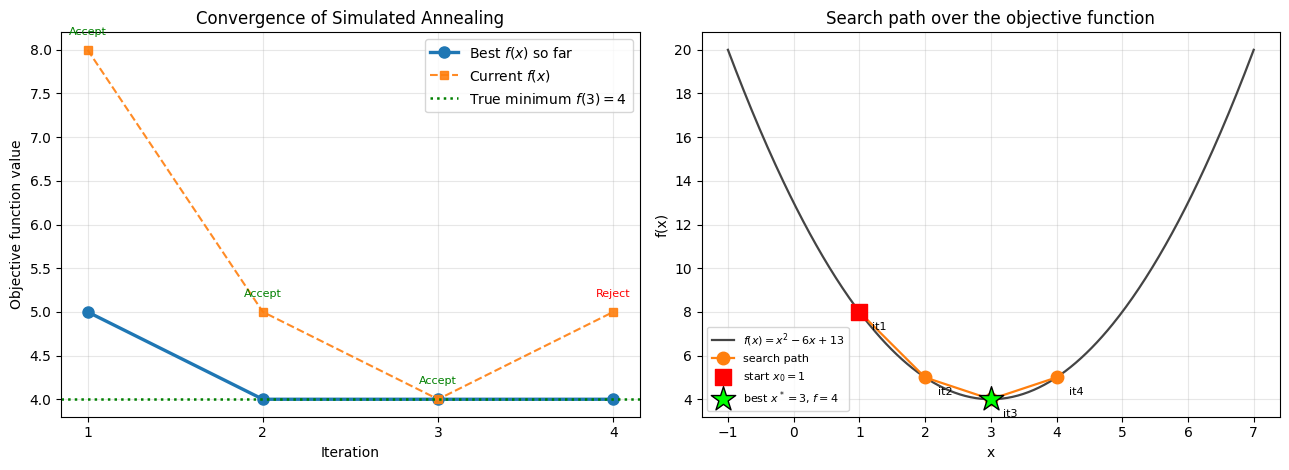

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))

it = hist['Iteration']
ax[0].plot(it, hist['Best f(x)'], 'o-', color='#1f77b4', lw=2.4, ms=8,
           label='Best $f(x)$ so far')
ax[0].plot(it, hist['f(x)'], 's--', color='#ff7f0e', lw=1.5, ms=6, alpha=0.9,
           label='Current $f(x)$')
ax[0].axhline(4, ls=':', c='green', lw=1.8, label='True minimum $f(3)=4$')
for _, r in hist.iterrows():
    ax[0].annotate(r['Decision'], (r['Iteration'], r['f(x)']),
                   textcoords='offset points', xytext=(0, 11), ha='center',
                   fontsize=8,
                   color='green' if r['Decision'] == 'Accept' else 'red')
ax[0].set_xticks(it)
ax[0].set_xlabel('Iteration'); ax[0].set_ylabel('Objective function value')
ax[0].set_title('Convergence of Simulated Annealing')
ax[0].legend(); ax[0].grid(alpha=0.3)

grid = np.linspace(-1, 7, 400)
ax[1].plot(grid, f(grid), color='#444', lw=1.6, label='$f(x)=x^2-6x+13$')
ax[1].plot(hist['Current x'], [f(v) for v in hist['Current x']], 'o-',
           color='#ff7f0e', ms=9, lw=1.6, label='search path')
ax[1].scatter([PARAMS['x0']], [f(PARAMS['x0'])], marker='s', s=140, c='red',
              zorder=5, label=f"start $x_0={PARAMS['x0']}$")
ax[1].scatter([best_x], [best_f], marker='*', s=340, c='lime', ec='k',
              zorder=6, label=f'best $x^*={best_x}$, $f={best_f}$')
for _, r in hist.iterrows():
    ax[1].annotate(f"it{int(r['Iteration'])}",
                   (r['Current x'], f(r['Current x'])),
                   textcoords='offset points', xytext=(9, -13), fontsize=8)
ax[1].set_xlabel('x'); ax[1].set_ylabel('f(x)')
ax[1].set_title('Search path over the objective function')
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

### 3.6 Acceptance probability against temperature

This isolates the mechanism of the algorithm: for a fixed worsening move, the
probability of accepting it collapses as the system cools. The circled points
are the two worsening moves actually proposed during the run.

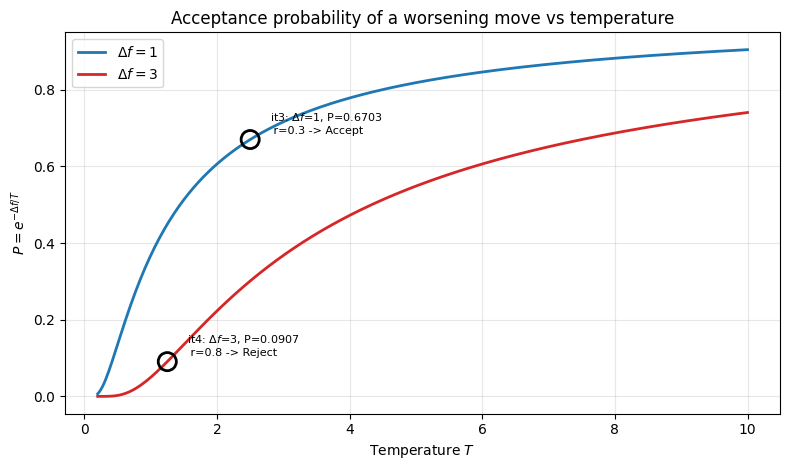

In [9]:
T_range = np.linspace(0.2, 10, 400)
plt.figure(figsize=(8, 4.8))
for d, col in [(1, '#1f77b4'), (3, '#d62728')]:
    plt.plot(T_range, np.exp(-d / T_range), color=col, lw=2,
             label=f'$\\Delta f = {d}$')

worse = hist[hist['Delta f'] >= 0]
for _, r in worse.iterrows():
    plt.scatter([r['T']], [r['P']], s=170, facecolors='none',
                edgecolors='black', lw=2, zorder=5)
    plt.annotate(f"it{int(r['Iteration'])}: $\\Delta f$={r['Delta f']:.0f}, "
                 f"P={r['P']:.4f}\n r={r['Random r']} -> {r['Decision']}",
                 (r['T'], r['P']), textcoords='offset points',
                 xytext=(14, 4), fontsize=8)

plt.xlabel('Temperature $T$'); plt.ylabel('$P = e^{-\\Delta f / T}$')
plt.title('Acceptance probability of a worsening move vs temperature')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 3.7 Parameter Modification

Each parameter is modified **one at a time** from the original configuration, so
that any change in the result is attributable to that parameter alone.

The original four-iteration run consumes only two of the four supplied random
numbers, so the longer runs below continue with a seeded random stream once the
supplied numbers are exhausted, and use the full neighbour rule
$x' = x \pm 1$. The same seed is used for every configuration, including the
baseline they are compared against.

| S. No. | Parameter | Original Value | Modified Value | Effect studied |
|---|---|---|---|---|
| 1 | Initial Temperature $T_0$ | 10 | 5 | Effect on exploration |
| 2 | Cooling Rate $\alpha$ | 0.5 | 0.9 | Effect on convergence |
| 3 | Stopping criterion $T_{min}$ (run length) | 1 | 0.01 | Effect on optimization |
| 4 | Initial Solution $x_0$ | 1 | 6 | Effect of starting point |

In [10]:
BASE = dict(x0=1, T0=10.0, alpha=0.5, T_min=1.0,
            random_numbers=(0.30, 0.80, 0.20, 0.90),
            direction='random', seed=7)

b_x, b_f, b_hist = simulated_annealing(**BASE)
print("General-form baseline (neighbour x' = x +/- 1, seeded):")
print(f"  x* = {b_x}, f(x*) = {b_f}, iterations = {len(b_hist)}")
print()

mods = [
    ('1', 'Initial Temperature T0',   'T0',    10.0, 5.0,  'Effect on exploration'),
    ('2', 'Cooling Rate alpha',       'alpha',  0.5, 0.9,  'Effect on convergence'),
    ('3', 'Stopping criterion T_min', 'T_min',  1.0, 0.01, 'Effect on optimization'),
    ('4', 'Initial Solution x0',      'x0',       1, 6,    'Effect of starting point'),
]

runs = {'Original': b_hist}
rows = []

for sno, label, key, orig_val, new_val, effect in mods:
    p = dict(BASE); p[key] = new_val
    mx, mf, mh = simulated_annealing(**p)
    runs[f'{label} = {new_val}'] = mh
    rows.append({
        'S. No.': sno, 'Parameter': label,
        'Original Value': orig_val, 'Modified Value': new_val,
        'Original Result': f'x* = {b_x}, f(x*) = {b_f}',
        'Modified Result': f'x* = {mx}, f(x*) = {mf}',
        'Iterations': f'{len(b_hist)} -> {len(mh)}',
        'Observation': effect,
    })

mod_table = pd.DataFrame(rows)
mod_table

General-form baseline (neighbour x' = x +/- 1, seeded):
  x* = 3, f(x*) = 4, iterations = 4



,S. No.,Parameter,Original Value,Modified Value,Original Result,Modified Result,Iterations,Observation
0,1,Initial Temperature T0,10.0,5.00,"x* = 3, f(x*) = 4","x* = 3, f(x*) = 4",4 -> 3,Effect on exploration
1,2,Cooling Rate alpha,0.5,0.90,"x* = 3, f(x*) = 4","x* = 3, f(x*) = 4",4 -> 22,Effect on convergence
2,3,Stopping criterion T_min,1.0,0.01,"x* = 3, f(x*) = 4","x* = 3, f(x*) = 4",4 -> 10,Effect on optimization
3,4,Initial Solution x0,1.0,6.00,"x* = 3, f(x*) = 4","x* = 6, f(x*) = 13",4 -> 4,Effect of starting point


### 3.8 Comparison of convergence under modified parameters

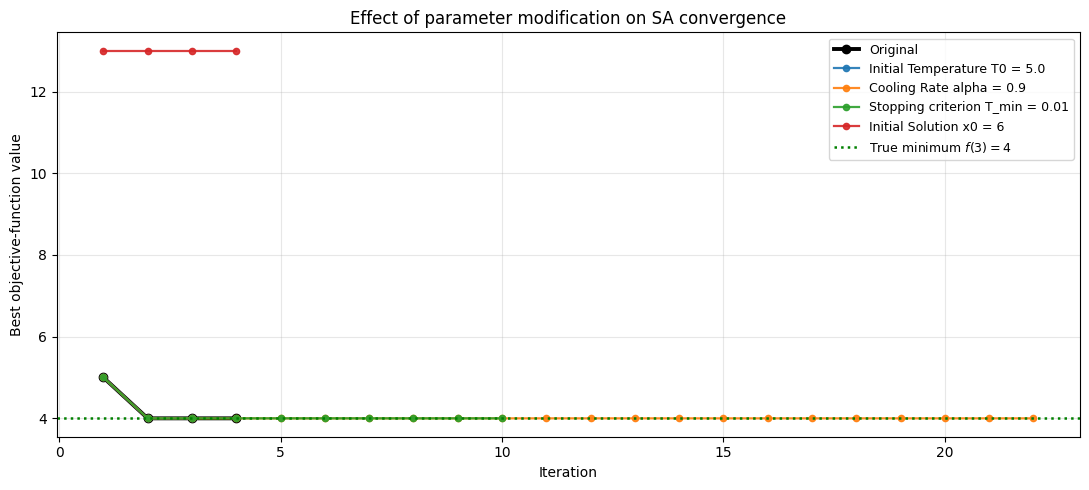

Iterations taken to first reach the true minimum f(x) = 4:
  Original                             :            2   (run length 4)
  Initial Temperature T0 = 5.0         :            2   (run length 3)
  Cooling Rate alpha = 0.9             :            2   (run length 22)
  Stopping criterion T_min = 0.01      :            2   (run length 10)
  Initial Solution x0 = 6              :  not reached   (run length 4)


In [11]:
plt.figure(figsize=(11, 5))
for name, h in runs.items():
    kw = dict(lw=2.8, color='black', marker='o', ms=6) if name == 'Original' \
         else dict(lw=1.6, alpha=0.9, marker='.', ms=9)
    plt.plot(h['Iteration'], h['Best f(x)'], label=name, **kw)
plt.axhline(4, ls=':', c='green', lw=1.8, label='True minimum $f(3)=4$')
plt.xlabel('Iteration'); plt.ylabel('Best objective-function value')
plt.title('Effect of parameter modification on SA convergence')
plt.legend(fontsize=9); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("Iterations taken to first reach the true minimum f(x) = 4:")
for name, h in runs.items():
    hit = h.index[h['Best f(x)'] <= 4]
    reached = int(h.loc[hit[0], 'Iteration']) if len(hit) else 'not reached'
    print(f"  {name:36s} : {str(reached):>12}   (run length {len(h)})")

### 3.9 Observations and Interpretation

**Original run.** Starting from $x_0 = 1$ where $f(x) = 8$, iterations 1 and 2
moved downhill ($x: 1 \to 2 \to 3$). Both were improvements, so they were
accepted unconditionally and consumed no random numbers at all — SA behaves
exactly like a hill-climber whenever the landscape cooperates.

At iteration 3 the current solution had already reached the true optimum
$x = 3$. The proposed neighbour $x' = 4$ was **worse** ($\Delta f = +1$), and
with $T = 2.5$ the acceptance probability was $P = e^{-1/2.5} \approx 0.6703$.
Since $r_1 = 0.30 < P$, the worse move was **accepted**. This is the defining
behaviour of Simulated Annealing: while still warm it will deliberately step
*away* from a good solution, so that it can never become permanently trapped in
whatever optimum it happens to occupy.

At iteration 4 the temperature had cooled to $T = 1.25$. The further worsening
move to $x' = 5$ ($\Delta f = +3$) gave a much smaller
$P = e^{-3/1.25} \approx 0.0907$, and since $r_2 = 0.80 > P$ the move was
**rejected**. The same algorithm, now cold, refuses the same kind of move it had
just accepted. After iteration 4, $T = 1.25 \times 0.5 = 0.625 < T_{min}$, so
the run stopped. $r_3$ and $r_4$ were never needed, because only two worsening
neighbours were ever proposed in this short run.

Although the *current* solution ended at $x = 4$, SA maintains the
**best-so-far** solution separately, and returned $x^* = 3$, $f(x^*) = 4$ —
matching the analytical result $f'(x) = 2x - 6 = 0 \Rightarrow x = 3$ exactly.

**1. Initial temperature $T_0$: 10 → 5 (exploration).**
$T_0$ fixes the size of the initial exploration budget, since
$P = e^{-\Delta f/T}$ is largest when $T$ is largest. Here it also fixes the run
length, because the stopping rule is a temperature threshold: halving $T_0$
removes one cooling step and therefore one iteration. The search explores less
and commits sooner. On this convex function that costs nothing — there is only
one basin to find — but on a multi-modal function a reduced $T_0$ directly
raises the risk of settling into a local rather than the global minimum.

**2. Cooling rate $\alpha$: 0.5 → 0.9 (convergence).**
This is the most consequential parameter. With $\alpha = 0.5$ the temperature
falls from 10 to below 1 in four steps; with $\alpha = 0.9$ it takes about
twenty-two. Slow cooling means many more iterations spent at moderate
temperature, so the algorithm wanders considerably before settling. Two
consequences pull in opposite directions: the search becomes far more robust at
escaping local minima, but it costs many more function evaluations and its
*current* solution stays noisy for much longer. A schedule that cools too
quickly is said to **quench** rather than anneal, and inherits precisely the
local-minimum weakness that SA exists to remove.

**3. Stopping criterion $T_{min}$: 1 → 0.01 (run length / optimization).**
Lowering $T_{min}$ extends the run into the very cold regime, where
$P \approx 0$ and essentially no worsening move is ever accepted. These extra
iterations can only refine within the current basin; they cannot escape one. The
best-so-far value therefore stops improving well before the run ends. The
practical lesson is that run length and cooling rate must be tuned
**together** — extra iterations buy nothing once the temperature has collapsed,
and would only pay off if $\alpha$ were raised alongside.

**4. Initial solution $x_0$: 1 → 6 (starting point).**
This is the one modification that **changed the answer**, and it is the most
informative result in the table. Starting from $x_0 = 6$ ($f = 13$), the run
returned $x^* = 6$, $f(x^*) = 13$ — the starting point itself. It found nothing
at all.

The reason is worth stating precisely. The run length here is not set by the
problem; it is set by the cooling schedule, since the loop terminates when
$T < T_{min}$. With $T_0 = 10$, $\alpha = 0.5$, $T_{min} = 1$ that is always
exactly four iterations, regardless of where the search begins. From $x_0 = 1$,
the optimum $x = 3$ is two steps away and the budget is ample. From $x_0 = 6$ it
is three steps away, and with the $x' = x \pm 1$ rule choosing direction at
random, roughly half of the proposals point the wrong way — and at $T = 10$,
$P = e^{-\Delta f/T}$ is close to 1, so those wrong-way moves are accepted.
Four iterations of a nearly-unbiased random walk is not enough to arrive.

Two things follow. First, the original run's success owes something to its
setup: starting at $x_0 = 1$ with the neighbour direction fixed upward points
the search straight at the optimum, so the four-iteration schedule is
sufficient almost by construction. Second, the fix is not to choose a better
starting point but to extend the budget — row 3 shows that simply lowering
$T_{min}$ to 0.01 stretches the run to ten iterations, which is enough. Run
length must be chosen to suit the problem, not left as a by-product of the
temperature threshold.

**Overall.** Simulated Annealing located the exact global minimum $x^* = 3$,
$f(x^*) = 4$, in agreement with the analytical solution. Performance is governed
mainly by the cooling schedule ($T_0$ and $\alpha$ together), only weakly by the
starting point, and not at all by additional iterations once the temperature has
collapsed — and, as row 4 shows, critically by whether the run is long enough
to reach the optimum from wherever it starts. One honest qualification: because
$f(x) = x^2 - 6x + 13$ is convex
with a single minimum, the probabilistic acceptance rule is not strictly
*required* here — a plain hill-climber would also find $x = 3$. This experiment
is therefore best read as a verification that the mechanism behaves as designed
on a case where the correct answer is known in advance, before applying it to
non-convex problems where that mechanism becomes essential.